# Research Methods for Business Analytics
## Group Project — World Happiness Report

**Dataset:** World Happiness Report  
**Course:** Research Methods for Business Analytics  
**Group:** TXA - A17

**Group Members:**
- 82715, Fabio Barbagallo
- 81204, Fabrice Keraudren
- 81245, Giacomo Aleotti

## Table of Contents

1. [Project Overview](#project-overview)
2. [Executive Summary](#executive-summary)
3. [Introduction](#introduction)
   - 3.1 [Importing the data](#importing-the-data)
4. [Data Cleaning](#data-cleaning)
   - 4.1 [Standardizing Column Names and Combining Datasets](#standardizing-column-names-and-combining-datasets)
   - 4.2 [Handling Incomplete Country Coverage](#handling-incomplete-country-coverage)
   - 4.3 [Handling Missing Values](#handling-missing-values)
5. [Exploratory Data Analysis](#exploratory-data-analysis)
   - 5.1 [Types of Variables](#types-of-variables)
   - 5.2 [Descriptive Statistics](#descriptive-statistics)
     - 5.2.1 [Frequencies](#521-frequencies)
     - 5.2.2 [Measures of Central Tendency](#522-measures-of-central-tendency)
     - 5.2.3 [Correlations](#523-correlations)
     - 5.2.4 [Summary Statistics Table](#524-summary-statistics-table)
6. [Method 1](#method-1)
7. [Method 2](#method-2)
8. [Reflection on the use of AI](#reflection-on-the-use-of-ai)
9. [Conclusion](#conclusion)
10. [References](#references)

## Project Overview

The goal of this project is to apply statistical methods from the Research Methods for Business Analytics course to a real-world dataset.

We use the **World Happiness Report** dataset (https://www.kaggle.com/datasets/unsdsn/world-happiness) to investigate differences and relationships in national happiness levels and their potential explanatory factors.

The project will:
1. explore and understand the dataset,
2. formulate a research question,
3. define two testable hypotheses,
4. perform exploratory data analysis,
5. test the hypotheses using two different statistical methods,
6. interpret the results,
7. discuss limitations and possible improvements.

The final research question and statistical methods will be selected after the initial exploratory analysis of the dataset.

## Executive Summary

XXXXXXXXXXXXXXXXXXXXXXx
This section will summarize the main research question, methods, key findings, and conclusions of the project once the statistical analysis has been completed.

The final executive summary will briefly cover:

the objective of the study,
the main characteristics of the World Happiness dataset,
the research question and hypotheses,
the statistical methods used,
the most important results, and
the main conclusions and limitations.
XXXXXXXXXXXXXXXXXXXXXXx


## Introduction

Happiness is influenced by a wide range of economic and social factors. The World Happiness Report we analyse provides country-level data from 2015 to 2019 that allows us to investigate how happiness differs across countries and over time, and how it is associated with factors such as economic conditions, social support, health, freedom, generosity, and perceptions of corruption.

Before formulating our research question and hypotheses, we conduct an initial exploratory analysis. The purpose of this analysis is to understand:
- the structure and size of the dataset,
- the variables available for analysis,
- the time period and countries covered,
- whether values are missing, and
- the distributions of the main variables.

Based on these exploratory findings, we will formulate a research question with an original angle and select two statistical methods to test the corresponding hypotheses.

### Importing the data

The dataset contains five separate CSV files for each year 2015-2019 in the 'data' folder. Since the structure and naming of variables may differ between years, we initially load each year separately before combining the datasets.

In [1]:
import pandas as pd

# import the datasets individually
df_2015 = pd.read_csv("data/2015.csv")
df_2016 = pd.read_csv("data/2016.csv")
df_2017 = pd.read_csv("data/2017.csv")
df_2018 = pd.read_csv("data/2018.csv")
df_2019 = pd.read_csv("data/2019.csv")

# print the column names for each dataset
print("2015:", df_2015.columns.tolist())
print("2016:", df_2016.columns.tolist())
print("2017:", df_2017.columns.tolist())
print("2018:", df_2018.columns.tolist())
print("2019:", df_2019.columns.tolist())

2015: ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']
2016: ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Lower Confidence Interval', 'Upper Confidence Interval', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']
2017: ['Country', 'Happiness.Rank', 'Happiness.Score', 'Whisker.high', 'Whisker.low', 'Economy..GDP.per.Capita.', 'Family', 'Health..Life.Expectancy.', 'Freedom', 'Generosity', 'Trust..Government.Corruption.', 'Dystopia.Residual']
2018: ['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']
2019: ['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social sup

## Data Cleaning

### Standardizing Column Names and Combining Datasets

The five yearly datasets have different column names and structures. We standardize the column names to create a unified dataset that combines all years, then add a year variable to identify when each observation was recorded.

In [2]:
# create a mapping of the columnn names to a single unified convention
column_map = {
    "Country": "country",
    "Country or region": "country",

    "Region": "region",

    "Happiness Rank": "happiness_rank",
    "Happiness.Rank": "happiness_rank",
    "Overall rank": "happiness_rank",

    "Happiness Score": "happiness_score",
    "Happiness.Score": "happiness_score",
    "Score": "happiness_score",

    "Economy (GDP per Capita)": "gdp_per_capita",
    "Economy..GDP.per.Capita.": "gdp_per_capita",
    "GDP per capita": "gdp_per_capita",

    "Family": "social_support",
    "Social support": "social_support",

    "Health (Life Expectancy)": "healthy_life_expectancy",
    "Health..Life.Expectancy.": "healthy_life_expectancy",
    "Healthy life expectancy": "healthy_life_expectancy",

    "Freedom": "freedom",
    "Freedom to make life choices": "freedom",

    "Trust (Government Corruption)": "corruption_perception",
    "Trust..Government.Corruption.": "corruption_perception",
    "Perceptions of corruption": "corruption_perception",

    "Generosity": "generosity"
}

# rename all the columns in the datasets
df_2015 = df_2015.rename(columns=column_map)
df_2016 = df_2016.rename(columns=column_map)
df_2017 = df_2017.rename(columns=column_map)
df_2018 = df_2018.rename(columns=column_map)
df_2019 = df_2019.rename(columns=column_map)

# the identified common columns are the following
common_columns = [
    "year", # adding a year columns for each dataset to identify the year of the data
    "country",
    "happiness_rank",
    "happiness_score",
    "gdp_per_capita",
    "social_support",
    "healthy_life_expectancy",
    "freedom",
    "corruption_perception",
    "generosity"
]

# add the column year for each dataset as seperate column "year"
df_2015["year"] = 2015
df_2016["year"] = 2016
df_2017["year"] = 2017
df_2018["year"] = 2018
df_2019["year"] = 2019

# putting all the datasets together into one dataset
df = pd.concat([
    df_2015[common_columns],
    df_2016[common_columns],
    df_2017[common_columns],
    df_2018[common_columns],
    df_2019[common_columns]
], ignore_index=True)

# print the shape (number of rows and columns) of df
print("Shape:", df.shape)
# print the first 5 rows of the combined dataset
df.head()

Shape: (782, 10)


,year,country,happiness_rank,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom,corruption_perception,generosity
0,2015,Switzerland,1,7.587,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678
1,2015,Iceland,2,7.561,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630
2,2015,Denmark,3,7.527,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139
3,2015,Norway,4,7.522,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699
4,2015,Canada,5,7.427,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811


In [3]:
# display the data types of each column in the combined dataset
df.dtypes

year                         int64
country                        str
happiness_rank               int64
happiness_score            float64
gdp_per_capita             float64
social_support             float64
healthy_life_expectancy    float64
freedom                    float64
corruption_perception      float64
generosity                 float64
dtype: object

In [4]:
df["year"].value_counts().sort_index()

year
2015    158
2016    157
2017    155
2018    156
2019    156
Name: count, dtype: int64

### Handling Incomplete Country Coverage

The combined dataset includes data from multiple years, but not all countries appear in every year. Some inconsistencies also exist in country naming conventions across different years (e.g., "Hong Kong" vs "Hong Kong S.A.R., China"). We examine country coverage and standardize country names to ensure consistency.

In [5]:
# get the country names and remove any leading or trailing whitespace
df["country"] = df["country"].str.strip() 

# check for each country, in how many year does it appears
years_per_country = df.groupby("country")["year"].apply(list) 

# get the countries that are not present in all years
incomplete = years_per_country[years_per_country.apply(len) < 5] 

print("distinct countries (before merging):", df["country"].nunique())
print("Names not present in all years:", len(incomplete), "\n")
print(incomplete.to_string())

distinct countries (before merging): 170
Names not present in all years: 29 

country
Angola                      [2015, 2016, 2017, 2018]
Belize                            [2016, 2017, 2018]
Central African Republic    [2015, 2017, 2018, 2019]
Comoros                           [2015, 2016, 2019]
Djibouti                                      [2015]
Gambia                                        [2019]
Hong Kong                   [2015, 2016, 2018, 2019]
Hong Kong S.A.R., China                       [2017]
Laos                        [2015, 2016, 2018, 2019]
Lesotho                     [2015, 2017, 2018, 2019]
Macedonia                   [2015, 2016, 2017, 2018]
Mozambique                  [2015, 2017, 2018, 2019]
Namibia                     [2016, 2017, 2018, 2019]
North Cyprus                      [2015, 2016, 2017]
North Macedonia                               [2019]
Northern Cyprus                         [2018, 2019]
Oman                                          [2015]
Puerto Rico  

some countries appear twice in this list, because the naming is inconsistent across the years. We will standardize this before continuing.

In [6]:
# map each alternative spelling to one standard name
country_names = {
    "Hong Kong S.A.R., China": "Hong Kong",
    "Taiwan Province of China": "Taiwan",
    "Trinidad & Tobago": "Trinidad and Tobago",
    "North Cyprus": "Northern Cyprus",
    "Macedonia": "North Macedonia",
    "Somaliland region": "Somaliland Region",
}
# overwrite the country names with the standardized names
df["country"] = df["country"].replace(country_names)

# check the result
years_per_country = df.groupby("country")["year"].nunique()
print("Distinct countries after standardization:", df["country"].nunique())
print("Countries present in all five years     :", (years_per_country == 5).sum())

# check: standardizing names must not create duplicates (same country twice in one year)
print("Duplicated country-year pairs           :", df.duplicated(subset=["country", "year"]).sum())

Distinct countries after standardization: 164
Countries present in all five years     : 146
Duplicated country-year pairs           : 0


### Handling Missing Values

Before further analyzing the variables in descriptive statistics, we check whether the combined dataset contains missing values. Missing observations are important because they may affect which variables can be used in the later statistical analysis.

In [7]:
# check missing values
df.isna().sum()

year                       0
country                    0
happiness_rank             0
happiness_score            0
gdp_per_capita             0
social_support             0
healthy_life_expectancy    0
freedom                    0
corruption_perception      1
generosity                 0
dtype: int64

In [8]:
# checking which country has the missing value
df[df.isna().any(axis=1)]

,year,country,happiness_rank,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom,corruption_perception,generosity
489,2018,United Arab Emirates,20,6.774,2.096,0.776,0.67,0.284,NaN,0.186


The dataset contains one missing value for the corruption perception for the UAE in 2018. 
Based on this dataset alone, we cannot determine why this value is missing or classify the mechanism as MCAR, MAR, or MNAR. However, since this is the only missing value in the entire dataset, we do not believe it is missing completely at random (MCAR). It may be MNAR (Missing Not At Random), because the government of the UAE did not publish the data for this metric in that year. 

Since we would like to keep the observation and not drop it at this point, we will examine the corruption perception values for the UAE and use linear interpolation of the neighbouring years to estimate the 2018 value.

In [9]:
uae = df[df["country"] == "United Arab Emirates"]
print(uae[["country", "year", "corruption_perception"]].to_string(index=False))

             country  year  corruption_perception
United Arab Emirates  2015                0.38583
United Arab Emirates  2016                0.35561
United Arab Emirates  2017                0.32449
United Arab Emirates  2018                    NaN
United Arab Emirates  2019                0.18200


In [10]:
# We will impute the **mean** of the neighbouring years (2017 and 2019), as we see a negative trend in the corruption perception index during this time period
uae_2017 = df.loc[(df["country"] == "United Arab Emirates") & (df["year"] == 2017), "corruption_perception"].iloc[0]
uae_2019 = df.loc[(df["country"] == "United Arab Emirates") & (df["year"] == 2019), "corruption_perception"].iloc[0]

# impute the 2018 value with the average of 2017 and 2019
imputed_value = (uae_2017 + uae_2019) / 2
df.loc[(df["country"] == "United Arab Emirates") & (df["year"] == 2018), "corruption_perception"] = imputed_value

# check the result
print("Imputed value:", round(imputed_value, 3))
print("Missing values left:", df.isnull().sum().sum()) # checked isna and isnull

Imputed value: 0.253
Missing values left: 0


### Duplicate check

After standardizing the country names, we check whether the dataset contains completely duplicated rows or more than one observation for the same country and report year.

In [11]:
# 1. completely identical rows
print("Identical rows               :", df.duplicated().sum())

# 2. the same country more than once in the same year
print("Duplicated country-year pairs:", df.duplicated(subset=["country", "year"]).sum())


Identical rows               : 0
Duplicated country-year pairs: 0


## Exploratory Data Analysis

### Types of Variables

Our dataset contains both categorical and continuous variables. Understanding the measurement scale of each variable is essential for selecting appropriate statistical methods.

**Categorical Variables:**
- `year`: The year the observation was recorded (2015-2019). Although stored as integers, this is a categorical variable representing distinct time periods.
- `country`: The name of the country. This is a nominal variable with 164 distinct countries.
- `happiness_rank`: The rank of the country's happiness score within its year. This is an ordinal variable indicating relative position.

**Continuous Variables:**
- `happiness_score`: The World Happiness Report score on a scale from 0-10. This is a continuous variable representing overall national well-being.
- `gdp_per_capita`: Standardized measure of GDP per capita. Continuous variable representing economic development.
- `social_support`: Standardized measure of perceived social support. Continuous variable.
- `healthy_life_expectancy`: Standardized measure of life expectancy at birth. Continuous variable representing health outcomes.
- `freedom`: Standardized measure of perceived freedom to make life choices. Continuous variable.
- `corruption_perception`: Standardized measure of perceived corruption in government. Continuous variable.
- `generosity`: Standardized measure of charitable giving. Continuous variable.

Note: Standardized in this case does not mean z-standardized (mean = 0, 1 = one standard deviation), but that the approach and way of measurement is the same for all countries of a given year.

All continuous variables (except `happiness_score` and `happiness_rank`) have been standardized and are on scales where 0 represents the lowest and values from 1-2 represent the highest values observed in the dataset.

### Descriptive Statistics

#### 5.2.1 Frequencies

First, we examine the frequency distribution of the categorical variables to understand how countries are distributed across years.

In [12]:
variables = [
    "happiness_score",
    "gdp_per_capita",
    "social_support",
    "healthy_life_expectancy",
    "freedom",
    "corruption_perception",
    "generosity"
]

df[variables].describe()

,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom,corruption_perception,generosity
count,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000
mean,5.379018,0.916047,1.078392,0.612416,0.411091,0.125599,0.218576
std,1.127456,0.407340,0.329548,0.248309,0.152880,0.105847,0.122321
min,2.693000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.509750,0.606500,0.869363,0.440183,0.309768,0.054250,0.130000
50%,5.322000,0.982205,1.124735,0.647310,0.431000,0.091033,0.201982
75%,6.189500,1.236187,1.327250,0.808000,0.531000,0.156243,0.278832
max,7.769000,2.096000,1.644000,1.141000,0.724000,0.551910,0.838075


#### 5.2.2 Measures of Central Tendency

The descriptive statistics above show the mean, median (50th percentile), and standard deviation for each continuous variable. These measures help us understand the central location and spread of each variable in our dataset.

#### 5.2.3 Correlations

We examine correlations between continuous variables to identify potential relationships that may be worth investigating further in our hypothesis testing.

#### 5.2.4 Summary Statistics Table

Below is the summary statistics table for all continuous variables in our dataset:

### Extreme values

[explanation]

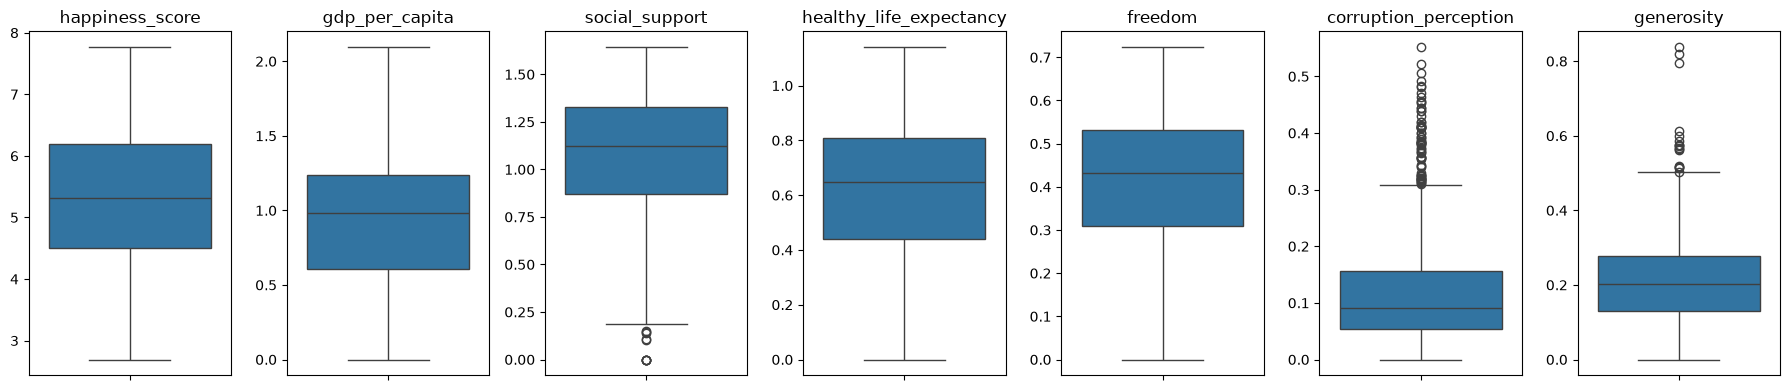

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns


factors = [
    "gdp_per_capita",
    "social_support",
    "healthy_life_expectancy",
    "freedom",
    "corruption_perception",
    "generosity"
]

variables = ["happiness_score"] + factors

# one boxplot per variable
fig, axes = plt.subplots(1, 7, figsize=(18, 4))
for ax, variable in zip(axes, variables):
    sns.boxplot(y=df[variable], ax=ax)
    ax.set_title(variable)
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

## Method 1

apply one method, test one hypothesis, explain why chosen, check key assumption, interpret results

## Method 2

apply one method, test one hypothesis, explain why chosen, check key assumption, interpret results

## Reflection on the use of AI

which tools, for what tasks, how (prompt examples), what the team added beyond AI output

## Conclusion

findings, limitations, ways to improve

## References